# Wine dataset (sklearn)

A Wine dataset a scikit-learn beépített adatbázisa, amely **borok kémiai jellemzőit** tartalmazza és osztályozási feladatokra használható.

## Adatok

- **Minták száma**: 178
- **Feature-ök száma**: 13 numerikus tulajdonság (pl. alkoholtartalom, savasság, stb.)
- **Osztályok száma**: 3 különböző bor típus
- **Cél**: meghatározni a bor típusát a kémiai jellemzők alapján

A feature-ök például:
- `alcohol`
- `malic_acid`
- `ash`
- `alcalinity_of_ash`
- `magnesium`
- `flavanoids`
- `proline`
... és továbbiak, összesen 13.

## 1. feladat: Adat betöltése

Olvasd be a Wine dataset-et a scikit-learn könyvtárból a `load_wine()` függvény segítségével, amit a `sklearn.datasets` modulban találsz

In [1]:
from sklearn.datasets import load_wine
import pandas as pd

# Wine dataset betöltése
data = load_wine()

# Feature-ök és target külön
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

## 2. feladat: Vizualizáció

- Készíts egy **osztályeloszlás vizualizációt** (`countplot`) a célváltozóhoz.
- Készíts egy **korrelációs mátrixot** (`heatmap`) az összes feature-re.
- A két ábrát tedd **egymás mellé** subplot-okban.

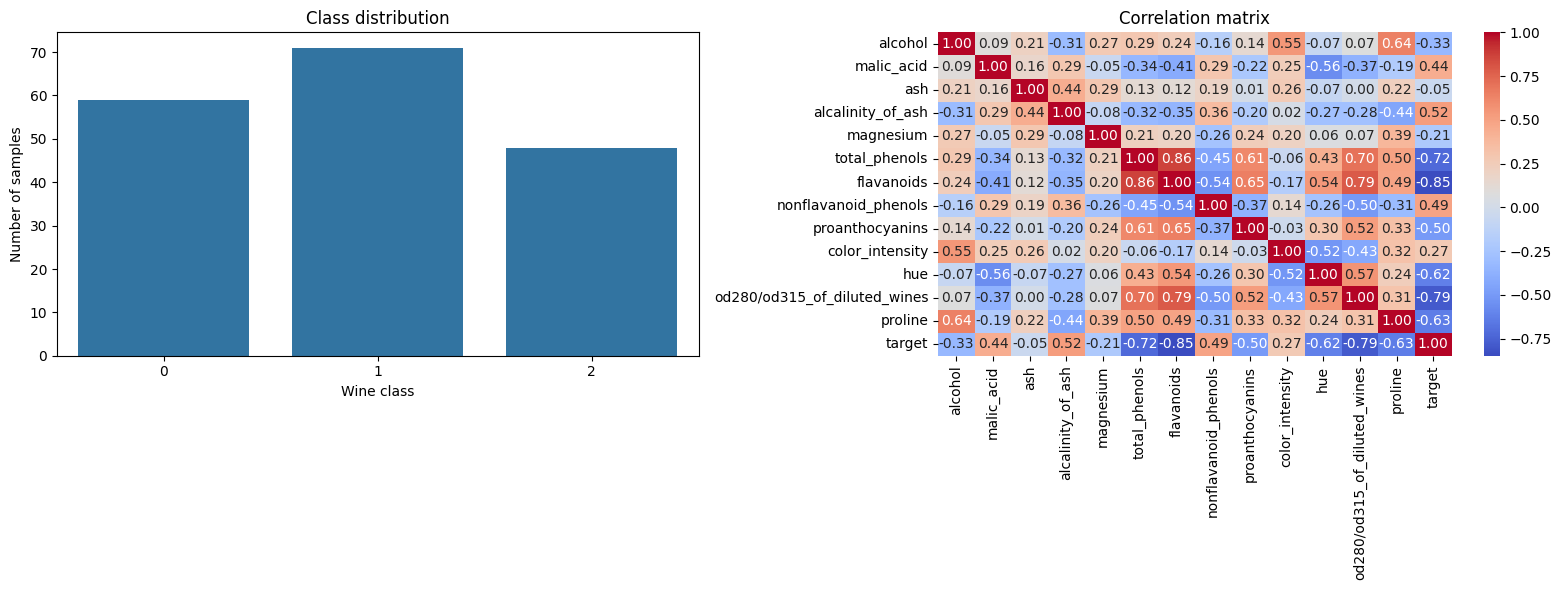

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Teljes DataFrame létrehozása targettel
df = X.copy()
df["target"] = y

# Két ábra egymás mellett
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# 1. Célosztály eloszlás
sns.countplot(x="target", data=df, ax=axes[0])
axes[0].set_xlabel("Wine class")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Class distribution")

# 2. Korrelációs mátrix
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation matrix")

plt.tight_layout()
plt.show()

## 3. feladat: Naive Bayes modell

- Oszd fel a Wine dataset-et **tanuló (train) és teszt (test) halmazra** (pl. 80-20% arányban).  
- Taníts egy **Gaussian Naive Bayes** modellt a tanuló adatokon.  
- Predikciók után nézd meg a **pontosságot** (`accuracy_score`) a teszt halmazon.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Adatok felosztása
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Naive Bayes modell létrehozása és tanítása
nb = GaussianNB()
nb.fit(X_train, y_train)

# 3. Predikció és pontosság
y_pred = nb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Naive Bayes Accuracy:", accuracy)

Naive Bayes Accuracy: 0.9722222222222222


## 4. feladat: Random Forest modell

- Használjuk a korábban létrehozott `X_train`, `X_test`, `y_train`, `y_test` adatokat.
- Taníts egy **Random Forest** modellt (pl. 100 fa, `random_state=42`).
- Nézd meg a modell **pontosságát** a teszt halmazon.

In [4]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest modell létrehozása és tanítása
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predikció és pontosság
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 1.0


## 5. feladat: Modellek értékelése

- Válaszd ki a **leggyengébben teljesítő modellt** a korábban tanultak közül.
- Készíts hozzá:
  1. **Confusion Matrix**-ot (`confusion_matrix` és `seaborn.heatmap` segítségével).
  2. **Classification Report**-ot (`classification_report`), ami tartalmazza a precision, recall és F1-score értékeket.

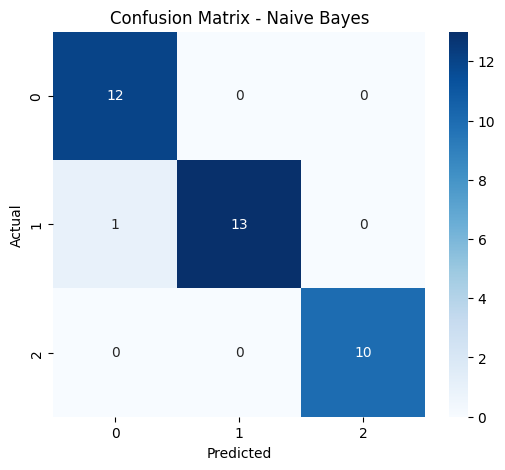

Classification Report - Naive Bayes:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [5]:
from sklearn.metrics import confusion_matrix, classification_report

# Példa: Naive Bayes használata a gyengébb modellként
y_pred_nb = nb.predict(X_test)

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

# 2. Classification Report
report = classification_report(y_test, y_pred_nb)
print("Classification Report - Naive Bayes:\n")
print(report)